In [32]:
import graphviz.backend as be

from sklearn.datasets import *
from dtreeviz.trees import *
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from IPython.display import Image, display

In [33]:
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier
from dtreeviz import model
import inspect
print(inspect.signature(model))

(model, X_train, y_train, tree_index: int = None, feature_names: List[str] = None, target_name: str = None, class_names: (typing.List[str], typing.Mapping[int, str]) = None, ai_chat: bool = False, ai_model: str = None, max_history_messages: int = 10) -> dtreeviz.trees.DTreeVizAPI


In [34]:
clas = DecisionTreeClassifier(max_depth=3)
iris = load_iris()

xtrain = iris.data
ytrain = iris.target
clas.fit(xtrain, ytrain)


,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples a

[Text(0.375, 0.875, 'x[3] <= 0.8\ngini = 0.667\nsamples = 150\nvalue = [50, 50, 50]'),
 Text(0.25, 0.625, 'gini = 0.0\nsamples = 50\nvalue = [50, 0, 0]'),
 Text(0.3125, 0.75, 'True  '),
 Text(0.5, 0.625, 'x[3] <= 1.75\ngini = 0.5\nsamples = 100\nvalue = [0, 50, 50]'),
 Text(0.4375, 0.75, '  False'),
 Text(0.25, 0.375, 'x[2] <= 4.95\ngini = 0.168\nsamples = 54\nvalue = [0, 49, 5]'),
 Text(0.125, 0.125, 'gini = 0.041\nsamples = 48\nvalue = [0, 47, 1]'),
 Text(0.375, 0.125, 'gini = 0.444\nsamples = 6\nvalue = [0, 2, 4]'),
 Text(0.75, 0.375, 'x[2] <= 4.85\ngini = 0.043\nsamples = 46\nvalue = [0, 1, 45]'),
 Text(0.625, 0.125, 'gini = 0.444\nsamples = 3\nvalue = [0, 1, 2]'),
 Text(0.875, 0.125, 'gini = 0.0\nsamples = 43\nvalue = [0, 0, 43]')]

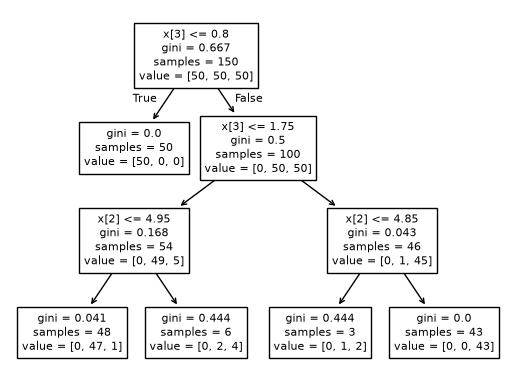

In [35]:
from sklearn.tree import plot_tree
plot_tree(clas)

In [36]:
import os
os.environ["PATH"] += os.pathsep + r"C:\Program Files\Graphviz\bin"


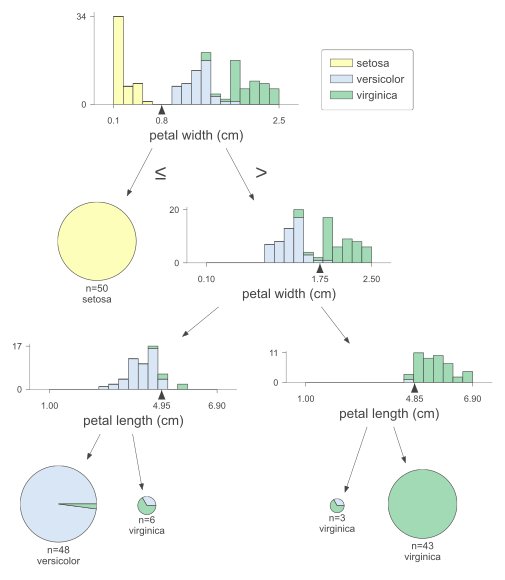

In [37]:
viz_model = model(
    clas,
    X_train=xtrain,
    y_train=ytrain,
    feature_names=iris.feature_names,
    class_names=["setosa", "versicolor", "virginica"],
)

viz_model.view(
    scale=1.5
)

regression

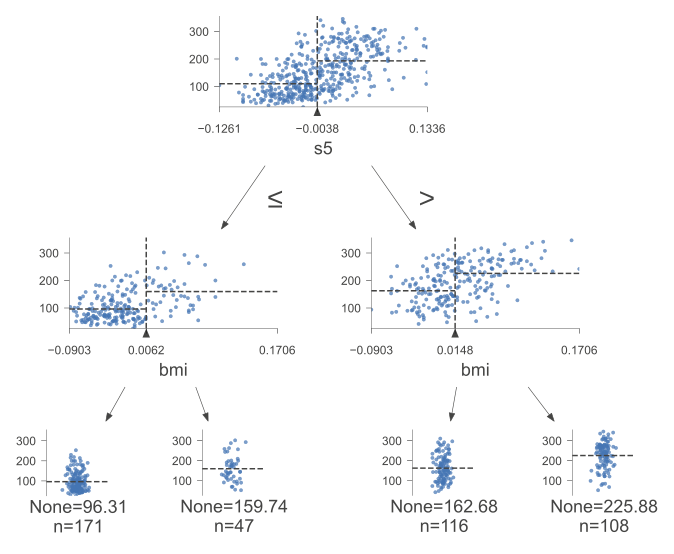

In [39]:
regr = DecisionTreeRegressor(max_depth=2)
load = load_diabetes()
x_train = load.data
y_train = load.target
regr.fit(x_train, y_train)

viz = model(regr, x_train, y_train, feature_names=load.feature_names)
viz.view(scale = 2)

horxontal decison trees

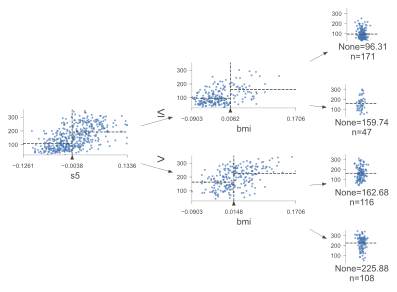

In [41]:
viz.view(orientation='LR')

show prediction path

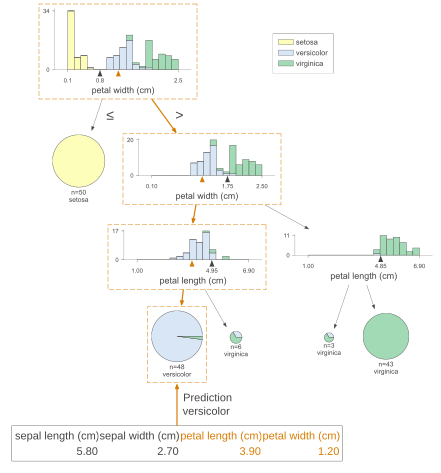

In [54]:
clas = DecisionTreeClassifier(max_depth=3)
iris = load_iris()

xtrain = iris.data
ytrain = iris.target
clas.fit(xtrain, ytrain)

x = iris.data[np.random.randint(0, len(iris.data)), :]

viz_model = model(
    clas,
    X_train=xtrain,
    y_train=ytrain,
    feature_names=iris.feature_names,
    class_names=["setosa", "versicolor", "virginica"],
    
)


# checking path of x
viz_model.view(
    x=x,
)

show node numbers 


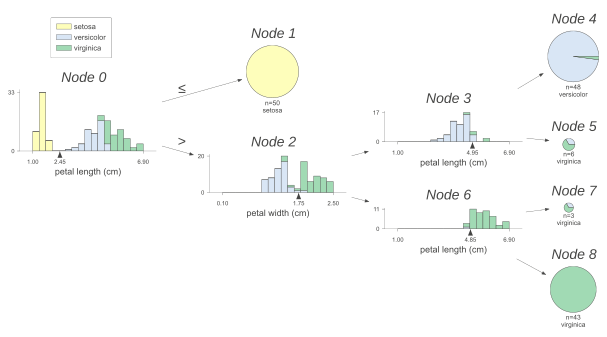

In [58]:
clas = DecisionTreeClassifier(max_depth=3)
iris = load_iris()

xtrain = iris.data
ytrain = iris.target
clas.fit(xtrain, ytrain)

x = iris.data[np.random.randint(0, len(iris.data)), :]

viz_model = model(
    clas,
    X_train=xtrain,
    y_train=ytrain,
    feature_names=iris.feature_names,
    class_names=["setosa", "versicolor", "virginica"],
    
)


# checking path of x
viz_model.view(
    show_node_labels=True, 
    orientation='LR'
)

without any graphs

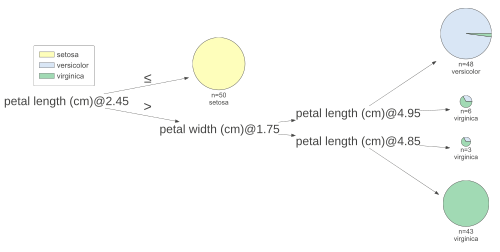

In [61]:
viz_model.view(
    orientation='LR',
    fancy=False
)

print path in english , feature importance can also be analysed